# Simulating the Earth-Sun-Moon System

**Companion lesson:** [`leapfrog_integration_lesson.md`](../docs/leapfrog_integration_lesson.md) explains *why* leapfrog is the right integrator. This notebook is the *how*. It builds [`earth_sun_moon_simulation.py`](earth_sun_moon_simulation.py) piece by piece, with all the code filled in and every step explained and checked.

By the end you will have:

1. described the Sun, Earth and Moon as `Body` objects with realistic masses, positions and velocities,
2. computed Newtonian gravity between every pair of bodies,
3. advanced the system in time with a **kick-drift-kick leapfrog** step,
4. measured the total energy to see how well the integrator behaves,
5. simulated 30 days and looked at the orbits, and
6. written the trajectories to CSV and SVG, the way the script does.

### How to use this notebook
- Run the cells top to bottom. Each function is defined in the cell that explains it, and later cells reuse it.
- Every function from the script appears here exactly as it is written there. The notebook adds explanation, checks and plots. Helper code that is *not* in the script is marked "new in this notebook".
- The notebook never writes into `datasets/` or `visualizations/`. Part 8 writes to a temporary folder and compares the result with the files the script produced, so running the notebook cannot change anything in your repo.
- Cells marked **✅ Check** assert something that must be true if the code above them is right. If one fails, its message says what to look at.

---
## Part 1: Bodies, units and initial conditions

We work in **SI units** everywhere: metres, kilograms, seconds. Mixing units (kilometres here, days there) is the classic way to get a simulation that runs but is wrong, so we pick one system and never leave it.

The only physical constant we need is Newton's gravitational constant $G$.

In [1]:
import csv
import tempfile
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import SVG, display

# Plot style shared by all the figures in this notebook (new in this notebook).
plt.style.use("dark_background")
plt.rcParams.update({"figure.facecolor": "#050b18", "axes.facecolor": "#050b18", "figure.dpi": 110})

G = 6.67430e-11  # m^3 kg^-1 s^-2

### A body is a point mass with a position and a velocity

The simulation is **two-dimensional**: everything happens in the $x$-$y$ plane. So the state of a body is its mass, its position $(x, y)$ and its velocity $(v_x, v_y)$. The `color` field is only used for drawing.

A `dataclass` gives us a tidy container. `Body("Earth", 5.97e24, x, y, vx, vy, "#3b82f6")` builds one, and we read or change `body.x`, `body.vy` and so on. The integrator will update these fields in place.

In [2]:
@dataclass
class Body:
    name: str
    mass: float
    x: float
    y: float
    vx: float
    vy: float
    color: str

### The Earth-Sun-Moon system

| Body | Mass (kg) | Position | Velocity |
|---|---|---|---|
| Sun | $1.988\times10^{30}$ | at the origin | at rest |
| Earth | $5.972\times10^{24}$ | $1\,\text{AU} = 1.496\times10^{11}$ m along $+x$ | $29.78$ km/s along $+y$ |
| Moon | $7.348\times10^{22}$ | $384{,}400$ km beyond the Earth, along $+x$ | the Earth's velocity plus $1.022$ km/s along $+y$ |

The geometry is a **full moon**: the Earth sits between the Sun and the Moon. Both the Earth (around the Sun) and the Moon (around the Earth) go counter-clockwise: position along $+x$, velocity along $+y$. The Moon's velocity is written as *the Earth's velocity plus the Moon's orbital velocity around the Earth*, because the Moon has to travel with the Earth around the Sun while it circles the Earth.

In [3]:
def create_earth_sun_moon_system() -> list[Body]:
    sun = Body("Sun", 1.98847e30, 0.0, 0.0, 0.0, 0.0, "#f6c431")
    earth = Body("Earth", 5.9722e24, 1.495978707e11, 0.0, 0.0, 29_780.0, "#3b82f6")
    moon = Body(
        "Moon",
        7.34767309e22,
        earth.x + 384_400_000.0,
        earth.y,
        earth.vx,
        earth.vy + 1_022.0,
        "#9ca3af",
    )
    return [sun, earth, moon]

### ✅ Check: are the starting speeds sensible?

A body on a circular orbit of radius $r$ around a mass $M$ moves at speed $\sqrt{GM/r}$. Our chosen speeds should be close to that, but not identical: real orbits are slightly elliptical, and $29.78$ km/s is the Earth's *average* speed.

The Sun starts at rest, so the system's **total momentum is not zero**. That means the centre of mass drifts slowly through space. We measure how much, to be sure it is negligible.

In [4]:
sun, earth, moon = create_earth_sun_moon_system()

v_circ_earth = np.sqrt(G * sun.mass / earth.x)
v_circ_moon = np.sqrt(G * earth.mass / (moon.x - earth.x))
print(f"Earth: circular-orbit speed {v_circ_earth:,.1f} m/s, chosen {earth.vy:,.1f} m/s")
print(f"Moon:  circular-orbit speed {v_circ_moon:,.1f} m/s, chosen {moon.vy - earth.vy:,.1f} m/s (relative to the Earth)")
assert np.isclose(earth.vy, v_circ_earth, rtol=1e-3) and np.isclose(moon.vy - earth.vy, v_circ_moon, rtol=1e-2)

total_mass = sun.mass + earth.mass + moon.mass
v_cm = (sun.mass * sun.vy + earth.mass * earth.vy + moon.mass * moon.vy) / total_mass
print(f"Centre-of-mass drift: {v_cm * 100:.1f} cm/s, which is {v_cm * 30 * 86_400 / 1e3:.0f} km in 30 days")
print("✅ The starting speeds are close to circular-orbit speeds, and the drift is negligible")

Earth: circular-orbit speed 29,785.1 m/s, chosen 29,780.0 m/s
Moon:  circular-orbit speed 1,018.3 m/s, chosen 1,022.0 m/s (relative to the Earth)
Centre-of-mass drift: 9.1 cm/s, which is 235 km in 30 days
✅ The starting speeds are close to circular-orbit speeds, and the drift is negligible


(The Keplerian notebook, [`keplerian_rv_fit.ipynb`](../machine_learning/keplerian_rv_fit.ipynb), sets up its two bodies with the centre of mass exactly at rest. Here the drift of about 230 km per month, against orbits a hundred million kilometres across, is not worth the extra code.)

---
## Part 2: Gravity

Newton's law says body $j$ pulls on body $i$ with a force of size $G m_i m_j / r_{ij}^2$, directed from $i$ towards $j$. Dividing by $m_i$ gives the **acceleration** of body $i$. Its own mass cancels, so a feather and a hammer fall the same way, and only the *other* body's mass matters:

$$\vec a_i = \sum_{j \ne i} \frac{G\,m_j}{r_{ij}^2}\,\hat r_{ij} = \sum_{j \ne i} G\,m_j\,\frac{\vec r_j - \vec r_i}{|\vec r_j - \vec r_i|^3}$$

where $\hat r_{ij}$ is the unit vector from $i$ to $j$. In the code, for every ordered pair $(i, j)$:

1. `dx, dy` is the vector from body $i$ to body $j$, and `dist` is its length.
2. `force_per_mass` $= G m_j / r^2$ is the *size* of the acceleration. ("Force per unit mass" is just acceleration.)
3. `dx / dist` and `dy / dist` are the components of the unit vector, so multiplying by them points the acceleration towards $j$.
4. The accelerations from all the other bodies simply add (the superposition principle).

Two details. The `dist == 0.0` guard skips a pair that sits at exactly the same point, which would otherwise divide by zero. (Physically that is a collision, and the simulation just ignores it.) And the cost grows as $N^2$. That is fine for three bodies, but far too slow for a galaxy, which is why real N-body codes use trees or the fast multipole method.

In [5]:
def compute_accelerations(bodies: list[Body]) -> list[tuple[float, float]]:
    """Newtonian gravitational acceleration on every body from every other body."""
    accelerations = []
    for i, body in enumerate(bodies):
        ax = 0.0
        ay = 0.0
        for j, other in enumerate(bodies):
            if i == j:
                continue
            dx = other.x - body.x
            dy = other.y - body.y
            dist_sq = dx * dx + dy * dy
            dist = dist_sq**0.5
            if dist == 0.0:
                continue
            force_per_mass = G * other.mass / dist_sq
            ax += force_per_mass * dx / dist
            ay += force_per_mass * dy / dist
        accelerations.append((ax, ay))
    return accelerations

### ✅ Check: gravity at $t = 0$

Two things we can verify by hand:

- At the start everything lies on the $x$-axis, so every acceleration points along $x$. The Earth is pulled towards the Sun (towards $-x$) by $G M_\odot / r^2$, and *slightly back outward* by the Moon, which is beyond it, by $G m_\text{Moon} / d^2$.
- **Newton's third law:** the forces $m_i \vec a_i$ must add up to zero, because every pull has an equal and opposite pull. The sum will not be *exactly* zero, since floating-point numbers are rounded, but it should be around $10^{-16}$ of a typical force.

In [6]:
sun, earth, moon = create_earth_sun_moon_system()
accelerations = compute_accelerations([sun, earth, moon])

expected_ax = -G * sun.mass / earth.x**2 + G * moon.mass / (moon.x - earth.x) ** 2
print(f"Earth's acceleration: {accelerations[1][0]:.6e} m/s^2 (by hand: {expected_ax:.6e})")
assert np.isclose(accelerations[1][0], expected_ax, rtol=1e-12) and accelerations[1][1] == 0.0

forces = np.array([[b.mass * ax, b.mass * ay] for b, (ax, ay) in zip([sun, earth, moon], accelerations)])
print(f"Net force: {forces.sum(axis=0)[0]:.1e} N, compared with the largest single force {np.abs(forces).max():.1e} N")
assert np.abs(forces.sum(axis=0)).max() < 1e-12 * np.abs(forces).max()
print("✅ Gravity matches the hand calculation, and the forces balance")

Earth's acceleration: -5.897074e-03 m/s^2 (by hand: -5.897074e-03)
Net force: 4.8e+06 N, compared with the largest single force 3.6e+22 N
✅ Gravity matches the hand calculation, and the forces balance


---
## Part 3: The leapfrog step

Now we need to move forward in time. The state changes according to $\dot{\vec x} = \vec v$ and $\dot{\vec v} = \vec a(\vec x)$. **Kick-drift-kick leapfrog** advances the system by one time step $\Delta t$ in three moves:

1. **Kick** (half-step velocity update): $$\vec v_{n+1/2} = \vec v_n + \vec a(\vec x_n)\,\tfrac{\Delta t}{2}$$
2. **Drift** (full-step position update): $$\vec x_{n+1} = \vec x_n + \vec v_{n+1/2}\,\Delta t$$
3. **Kick** (the other half-step): $$\vec v_{n+1} = \vec v_{n+1/2} + \vec a(\vec x_{n+1})\,\tfrac{\Delta t}{2}$$

The lesson explains why this arrangement, which is symmetric in time, keeps the energy error bounded. Here are the implementation details worth noticing:

- **The forces are computed in a separate pass.** Every position must be moved *before* any new acceleration is computed. Otherwise body 2 would feel where body 1 *will be*, not where it is. That is why `compute_accelerations` is its own function, called on a consistent snapshot of all the positions.
- **One force evaluation per step.** The acceleration at $\vec x_{n+1}$ used in the second kick is exactly the one the *next* step needs for its first kick. So `leapfrog_step` takes the accelerations at the current positions and returns the accelerations at the new positions, and the caller holds on to them between steps.
- **In-place update.** The function changes the `Body` objects directly. The first kick and the drift share a loop because both only need the accelerations that were passed in.

In [7]:
def leapfrog_step(
    bodies: list[Body], dt_seconds: float, accelerations: list[tuple[float, float]]
) -> list[tuple[float, float]]:
    """Advance bodies in place by one kick-drift-kick step.

    Takes the accelerations at the current positions and returns the accelerations
    at the new positions, so the caller can reuse them for the next step's first kick.
    """
    # 1. First KICK (half-step velocity) & DRIFT (full-step position)
    for body, (ax, ay) in zip(bodies, accelerations):
        body.vx += 0.5 * ax * dt_seconds
        body.vy += 0.5 * ay * dt_seconds
        body.x += body.vx * dt_seconds
        body.y += body.vy * dt_seconds

    # 2. Recalculate NEW accelerations based on NEW positions
    new_accelerations = compute_accelerations(bodies)

    # 3. Second KICK (half-step velocity) with NEW accelerations
    for body, (ax, ay) in zip(bodies, new_accelerations):
        body.vx += 0.5 * ax * dt_seconds
        body.vy += 0.5 * ay * dt_seconds

    return new_accelerations

### ✅ Check: leapfrog is time-reversible

A neat property of kick-drift-kick is its symmetry. Run $N$ steps forward, flip the sign of every velocity, and run $N$ more steps: you retrace your path and arrive back where you started (with the velocities flipped, so we flip them back to compare). A one-sided scheme has no such property, and its errors pile up in one direction.

On paper the return is exact. On a computer it holds up to floating-point round-off, which is tiny: millimetres to metres, on orbits that are $10^8$ to $10^{11}$ m across.

In [8]:
def snapshot(bodies):
    """Positions and velocities of all bodies as an array of rows [x, y, vx, vy] (new in this notebook)."""
    return np.array([[b.x, b.y, b.vx, b.vy] for b in bodies])


bodies = create_earth_sun_moon_system()
start = snapshot(bodies)
dt = 2 * 3600.0  # two hours

accelerations = compute_accelerations(bodies)
for _ in range(720):  # 60 days forward
    accelerations = leapfrog_step(bodies, dt, accelerations)

for b in bodies:  # flip the arrow of time
    b.vx, b.vy = -b.vx, -b.vy

accelerations = compute_accelerations(bodies)
for _ in range(720):  # 60 days "backward"
    accelerations = leapfrog_step(bodies, dt, accelerations)

for b in bodies:  # flip the velocities back so we can compare with the start
    b.vx, b.vy = -b.vx, -b.vy

position_error = np.hypot(*(snapshot(bodies) - start)[:, :2].T)
for b, err in zip(bodies, position_error):
    print(f"{b.name:>5}: back at its starting point to within {err:.1e} m")
assert position_error.max() < 1.0, "Running backwards should retrace the path to within round-off"
print("✅ 720 steps forward and 720 steps back return the system to its starting point")

  Sun: back at its starting point to within 1.5e-11 m
Earth: back at its starting point to within 5.1e-05 m
 Moon: back at its starting point to within 2.5e-03 m
✅ 720 steps forward and 720 steps back return the system to its starting point


---
## Part 4: Total energy, the integrator's report card

The exact equations of motion conserve the total energy

$$E = \underbrace{\sum_i \tfrac12 m_i |\vec v_i|^2}_{\text{kinetic}} \;-\; \underbrace{\sum_{i<j} \frac{G\,m_i m_j}{r_{ij}}}_{\text{potential}}$$

so any change of $E$ in the simulation is *numerical* error. That makes it the standard way to judge an integrator.

The potential energy belongs to each **pair** of bodies, so the code loops over $i < j$ (`bodies[i + 1:]`) to count every pair exactly once. Looping over all ordered pairs would double it.

In [9]:
def total_energy(bodies: list[Body]) -> float:
    """Kinetic plus gravitational potential energy of the system, in joules."""
    kinetic = sum(0.5 * body.mass * (body.vx**2 + body.vy**2) for body in bodies)
    potential = 0.0
    for i, body in enumerate(bodies):
        for other in bodies[i + 1 :]:
            dist = ((other.x - body.x) ** 2 + (other.y - body.y) ** 2) ** 0.5
            potential -= G * body.mass * other.mass / dist
    return kinetic + potential

### ✅ Check: the energy of a circular orbit

For a circular orbit $v^2 = GM/r$, so $E = \tfrac12 m v^2 - GMm/r = -\dfrac{GMm}{2r}$. (The kinetic energy equals minus the total energy: the virial theorem in miniature.) If we put the Earth at exactly the circular speed, `total_energy` should return that number.

In [10]:
sun_only = Body("Sun", 1.98847e30, 0.0, 0.0, 0.0, 0.0, "#f6c431")
r = 1.495978707e11
earth_circular = Body("Earth", 5.9722e24, r, 0.0, 0.0, np.sqrt(G * sun_only.mass / r), "#3b82f6")

expected = -G * sun_only.mass * earth_circular.mass / (2 * r)
energy = total_energy([sun_only, earth_circular])
print(f"total_energy = {energy:.6e} J, expected -GMm/2r = {expected:.6e} J")
assert np.isclose(energy, expected, rtol=1e-12)
print("✅ total_energy agrees with the analytic result")

total_energy = -2.649133e+33 J, expected -GMm/2r = -2.649133e+33 J
✅ total_energy agrees with the analytic result


---
## Part 5: Running the simulation

`simulate_n_body` is the time loop. It takes the bodies, a time step in seconds and a number of steps, and returns each body's path as a list of $(x, y)$ points. The list starts with the initial position, so $n$ steps give $n+1$ points.

It evaluates the accelerations once at the start. After that, each call to `leapfrog_step` hands back the accelerations for the next step, so gravity is computed once per step, not twice.

In [11]:
def simulate_n_body(bodies: list[Body], dt_seconds: float, steps: int) -> dict[str, list[tuple[float, float]]]:
    trajectories = {body.name: [(body.x, body.y)] for body in bodies}

    # The end-of-step accelerations are exactly the next step's starting accelerations,
    # so we only evaluate forces once per step.
    accelerations = compute_accelerations(bodies)
    for _ in range(steps):
        accelerations = leapfrog_step(bodies, dt_seconds, accelerations)
        for body in bodies:
            trajectories[body.name].append((body.x, body.y))

    return trajectories

### Choosing the time step

The step $\Delta t$ is the one knob. Too big and the integration error grows (Part 7 measures how fast). Too small and the run is slow. A common rule of thumb is to resolve the *fastest* motion in the system with at least about a hundred steps per orbit. Here the fastest motion is the Moon going round the Earth, roughly once every 27 days, and the script's default step of 2 hours gives about 320 steps per lunar orbit.

The script's defaults are 30 days at 2-hour steps.

In [12]:
days = 30.0
step_hours = 2.0
dt_seconds = step_hours * 3600
steps = int((days * 24) / step_hours)

bodies = create_earth_sun_moon_system()
trajectories = simulate_n_body(bodies, dt_seconds=dt_seconds, steps=steps)

print(f"{steps} steps of {step_hours:g} hours = {days:g} days")
for name, points in trajectories.items():
    x, y = points[-1]
    print(f"{name:>5}: {len(points)} points, ends at ({x:.4e}, {y:.4e}) m")
assert all(len(points) == steps + 1 for points in trajectories.values())

360 steps of 2 hours = 30 days
  Sun: 361 points, ends at (5.9230e+04, 1.0282e+04) m
Earth: 361 points, ends at (1.3012e+11, 7.3837e+10) m
 Moon: 361 points, ends at (1.3041e+11, 7.4090e+10) m


---
## Part 6: Looking at the orbits

Two views of the same 30 days.

- **Left, the Sun-centred view.** The scale is set by the Earth-Sun distance, so the Moon's path is invisible: it hides under the Earth's. The Earth covers about 30 degrees of its yearly orbit.
- **Right, the Moon relative to the Earth.** Subtracting the Earth's position reveals the Moon's motion: a near-circular orbit that closes after about a month. The Earth is drawn to scale (radius 6,371 km).

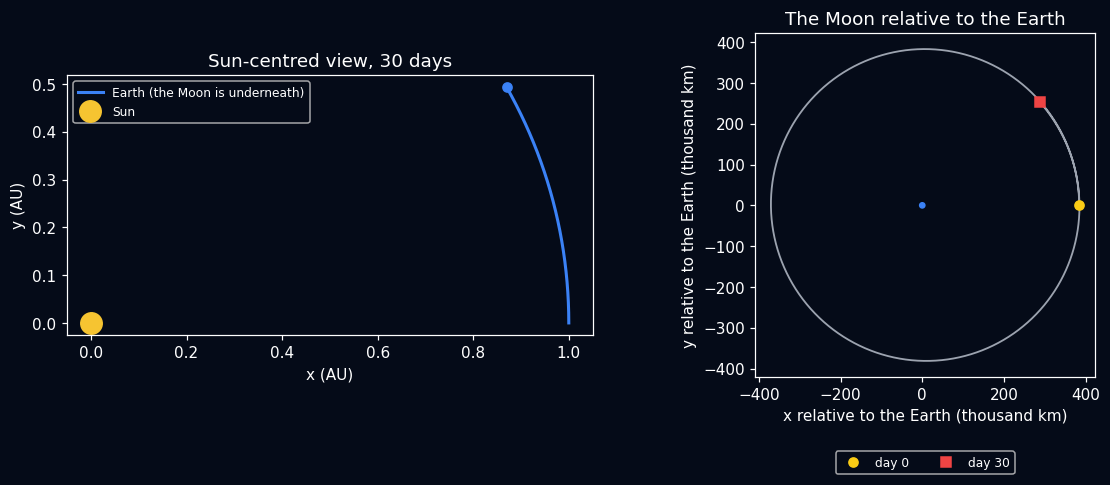

In [13]:
AU = 1.495978707e11  # metres

earth_path = np.array(trajectories["Earth"])
sun_path = np.array(trajectories["Sun"])
moon_path = np.array(trajectories["Moon"])
moon_rel = (moon_path - earth_path) / 1e6  # the Moon's position relative to the Earth, in thousand km

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))

ax1.plot(*(earth_path / AU).T, color="#3b82f6", lw=2, label="Earth (the Moon is underneath)")
ax1.plot(*(earth_path[-1] / AU), "o", color="#3b82f6", ms=6)
ax1.plot(*(sun_path[0] / AU), "o", color="#f6c431", ms=14, label="Sun")
ax1.set(xlabel="x (AU)", ylabel="y (AU)", title="Sun-centred view, 30 days", aspect="equal")
ax1.legend(loc="upper left", fontsize=8)

ax2.add_patch(plt.Circle((0, 0), 6.371, color="#3b82f6"))
ax2.plot(*moon_rel.T, color="#9ca3af", lw=1.2)
ax2.plot(*moon_rel[0], "o", color="#facc15", ms=6, label="day 0")
ax2.plot(*moon_rel[-1], "s", color="#ef4444", ms=6, label="day 30")
ax2.set(xlabel="x relative to the Earth (thousand km)", ylabel="y relative to the Earth (thousand km)",
        title="The Moon relative to the Earth", aspect="equal")
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=8)
fig.tight_layout()

### ✅ Check: does the Moon take about a month to go round?

The Moon's angle around the Earth, passed through `np.unwrap` so that it keeps growing instead of jumping back at $2\pi$, tells us when one full revolution is done. That is the *sidereal* month, whose real value is 27.32 days.

In [14]:
angle = np.unwrap(np.arctan2(moon_rel[:, 1], moon_rel[:, 0]))
turned = angle - angle[0]
assert turned.max() >= 2 * np.pi, "Simulate at least ~28 days to see a full lunar orbit"
time_days = np.arange(steps + 1) * step_hours / 24

i = int(np.argmax(turned >= 2 * np.pi))  # the first step at or past one full revolution
month = np.interp(2 * np.pi, turned[i - 1 : i + 1], time_days[i - 1 : i + 1])
distance_km = np.hypot(*moon_rel.T) * 1e3

print(f"Simulated sidereal month: {month:.2f} days (real value: 27.32 days)")
print(f"Earth-Moon distance ranged from {distance_km.min():,.0f} to {distance_km.max():,.0f} km")
assert abs(month / 27.32 - 1) < 0.05
print("✅ The Moon goes round the Earth in about a month")

Simulated sidereal month: 26.86 days (real value: 27.32 days)
Earth-Moon distance ranged from 370,527 to 386,146 km
✅ The Moon goes round the Earth in about a month


The simulated month comes out a little *shorter* than the real one. That is expected, not a bug: we launched the Moon exactly at full moon, at its *mean* distance and with its *mean* speed. That is not a point on the real, slightly eccentric orbit, and the Sun's tidal pull then pushes the Moon's orbit around, so an exact match would be a coincidence. The point of the check is that the engine gets the timescale right to a couple of per cent.

---
## Part 7: How good is the energy conservation?

Part 3 claimed that leapfrog's energy error stays **bounded** (there is no slow drift) and shrinks like $\Delta t^2$ when the step is made smaller. Now we can measure both.

`simulate_n_body` only returns positions, so here is a variant of the same loop that also records the relative energy error $(E - E_0)/|E_0|$ after every step. This helper is **new in this notebook**. The script does not track energy.

In [15]:
def relative_energy_error(step_hours: float, days: float) -> np.ndarray:
    """(E - E0) / |E0| after every leapfrog step, starting from the initial system (new in this notebook)."""
    bodies = create_earth_sun_moon_system()
    dt_seconds = step_hours * 3600
    steps = int(days * 24 / step_hours)
    energy0 = total_energy(bodies)
    errors = np.zeros(steps + 1)
    accelerations = compute_accelerations(bodies)
    for n in range(1, steps + 1):
        accelerations = leapfrog_step(bodies, dt_seconds, accelerations)
        errors[n] = (total_energy(bodies) - energy0) / abs(energy0)
    return errors

step (h)   largest |dE/E0|   ratio to the previous step size
       4       4.384e-09   
       2       1.093e-09   4.01
       1       2.731e-10   4.00
     0.5       6.829e-11   4.00


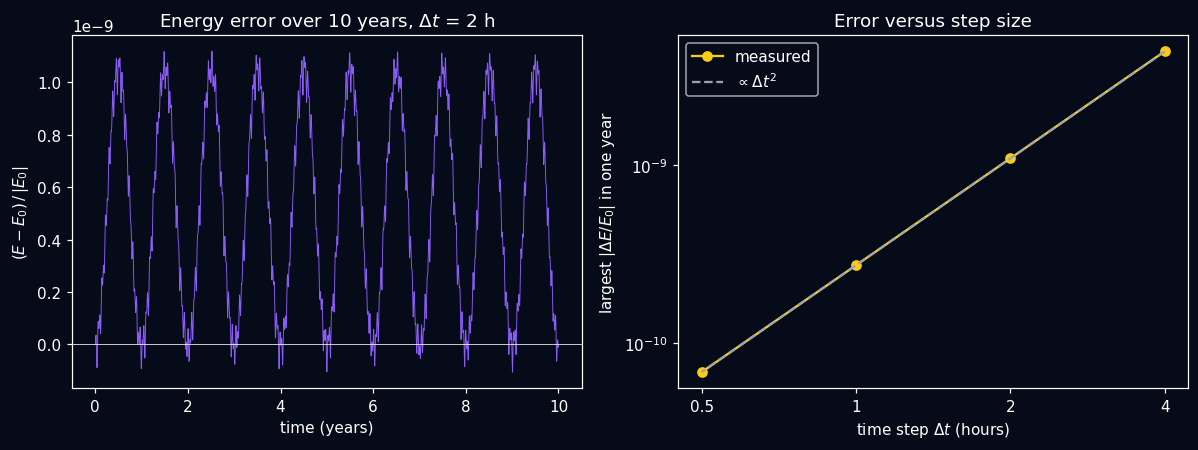

In [16]:
# 10 years at the script's default step of 2 hours...
error_10yr = relative_energy_error(step_hours=2.0, days=365.25 * 10)
time_years = np.arange(len(error_10yr)) * 2.0 / 24 / 365.25

# ...and 1 year at several step sizes.
step_sizes = np.array([4.0, 2.0, 1.0, 0.5])  # hours
max_errors = np.array([np.abs(relative_energy_error(h, 365.25)).max() for h in step_sizes])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(time_years, error_10yr, color="#8b5cf6", lw=0.6)
ax1.axhline(0, color="white", lw=0.5)
ax1.set(xlabel="time (years)", ylabel=r"$(E - E_0)\,/\,|E_0|$", title=r"Energy error over 10 years, $\Delta t$ = 2 h")

ax2.loglog(step_sizes, max_errors, "o-", color="#facc15", label="measured")
ax2.loglog(step_sizes, max_errors[1] * (step_sizes / step_sizes[1]) ** 2, "--", color="#9ca3af", label=r"$\propto \Delta t^2$")
ax2.set(xlabel=r"time step $\Delta t$ (hours)", ylabel=r"largest $|\Delta E / E_0|$ in one year", title="Error versus step size")
ax2.set_xticks(step_sizes, [f"{h:g}" for h in step_sizes])  # label the ticks with the step sizes we actually used
ax2.minorticks_off()
ax2.legend()
fig.tight_layout()

slopes = np.diff(np.log(max_errors)) / np.diff(np.log(step_sizes))
print("step (h)   largest |dE/E0|   ratio to the previous step size")
for h, err, prev in zip(step_sizes, max_errors, [None, *max_errors[:-1]]):
    print(f"{h:8g}   {err:13.3e}   " + ("" if prev is None else f"{prev / err:.2f}"))

### ✅ Check: bounded, and second order

Two claims to confirm:

- **No drift.** The largest error in the last five years should be no bigger than in the first five. (If the error grew steadily, this is where it would show.)
- **Second order.** Halving $\Delta t$ should cut the error by a factor of 4, i.e. a slope of 2 on the log-log plot.

In [17]:
half = len(error_10yr) // 2
early, late = np.abs(error_10yr[:half]).max(), np.abs(error_10yr[half:]).max()
print(f"Largest |error| in the first 5 years: {early:.3e}, in the last 5 years: {late:.3e}")
assert late < 1.1 * early, "The energy error should not grow with time"

print(f"Slopes of error versus step size: {np.round(slopes, 2)}")
assert np.allclose(slopes, 2, atol=0.1), "The energy error should scale as the step size squared"
print("✅ The energy error is bounded, and it scales as the step size squared")

Largest |error| in the first 5 years: 1.119e-09, in the last 5 years: 1.117e-09
Slopes of error versus step size: [2. 2. 2.]
✅ The energy error is bounded, and it scales as the step size squared


The error never exceeds about $10^{-9}$ of the total energy, and it repeats year after year instead of growing. It also sits mostly on one side of zero. Both are what the *shadow Hamiltonian* picture from the lesson predicts: leapfrog conserves a slightly different energy $H'$ to extremely high accuracy, so the true energy $H$ can only wobble around it.

---
## Part 8: Saving the results

The script ends by writing the trajectories to disk in two formats. Both writers take the `trajectories` dictionary from Part 5.

### CSV: one row per body per step

`write_trajectories_csv` produces a "long" table with the columns `body, step, x_m, y_m`, which loads straight into pandas or a spreadsheet. (`newline=""` is what the `csv` module's documentation asks for when you open the file yourself.)

In [18]:
def write_trajectories_csv(trajectories: dict[str, list[tuple[float, float]]], output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.writer(handle)
        writer.writerow(["body", "step", "x_m", "y_m"])
        for body_name, points in trajectories.items():
            for step, (x, y) in enumerate(points):
                writer.writerow([body_name, step, x, y])

### SVG: a picture without a plotting library

`write_trajectories_svg` writes the picture by hand. SVG is just text: a `<polyline>` is a path through a list of points, a `<circle>` marks where each body ends up, and a `<text>` labels it.

The one piece of maths is `to_viewport`, which maps physical coordinates in metres onto the 900 by 900 pixel canvas:

$$\text{view}_x = \text{padding} + \frac{x - x_{\min}}{x_{\max} - x_{\min}}\,(\text{width} - 2\,\text{padding})$$

The vertical coordinate is flipped (`height - ...`) because SVG's $y$ axis points *down* the screen, while ours points up. Note that $x$ and $y$ are rescaled **independently**, so the picture fills the canvas but its aspect ratio is not preserved. Compare it with the equal-aspect plot in Part 6.

In [19]:
def write_trajectories_svg(trajectories: dict[str, list[tuple[float, float]]], output_path: Path, days: float, step_hours: float) -> None:
    all_points = [point for points in trajectories.values() for point in points]
    min_x = min(x for x, _ in all_points)
    max_x = max(x for x, _ in all_points)
    min_y = min(y for _, y in all_points)
    max_y = max(y for _, y in all_points)

    width = 900
    height = 900
    padding = 60

    span_x = max(max_x - min_x, 1.0)
    span_y = max(max_y - min_y, 1.0)

    def to_viewport(x: float, y: float) -> tuple[float, float]:
        norm_x = (x - min_x) / span_x
        norm_y = (y - min_y) / span_y
        view_x = padding + norm_x * (width - 2 * padding)
        view_y = height - (padding + norm_y * (height - 2 * padding))
        return view_x, view_y

    palette = {
        "Sun": "#f6c431",
        "Earth": "#3b82f6",
        "Moon": "#9ca3af",
    }

    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open("w", encoding="utf-8") as handle:
        handle.write("<svg xmlns='http://www.w3.org/2000/svg' width='900' height='900' viewBox='0 0 900 900'>\n")
        handle.write("  <rect width='100%' height='100%' fill='#050b18'/>\n")
        handle.write(f"  <text x='20' y='35' fill='white' font-size='22'>Earth-Sun-Moon n-body simulation ({days} days, {step_hours} hour intervals)</text>\n")
        for body_name, points in trajectories.items():
            converted = [to_viewport(x, y) for x, y in points]
            path_points = " ".join(f"{x:.2f},{y:.2f}" for x, y in converted)
            color = palette.get(body_name, "#ffffff")
            handle.write(f"  <polyline points='{path_points}' fill='none' stroke='{color}' stroke-width='1.6'/>\n")
            final_x, final_y = converted[-1]
            handle.write(f"  <circle cx='{final_x:.2f}' cy='{final_y:.2f}' r='4' fill='{color}'/>\n")
            handle.write(
                f"  <text x='{final_x + 8:.2f}' y='{final_y - 8:.2f}' fill='{color}' font-size='14'>{body_name}</text>\n"
            )

        handle.write("</svg>\n")

### Try the writers (in a temporary folder)

The script writes into `datasets/` and `visualizations/`. To keep this notebook from touching your repo, we write into a temporary folder instead, read the files back, and then compare them with the ones the script produced.

CSV: 1083 data rows (3 bodies x 361 points). The first rows:
body,step,x_m,y_m
Sun,0,0.0,0.0
Sun,1,0.4673129281659206,0.0
Sun,2,1.8692507508307656,0.001340095780783331

datasets/earth_sun_moon_trajectories.csv: identical to the copy produced by the script
visualizations/earth_sun_moon_simulation.svg: identical to the copy produced by the script


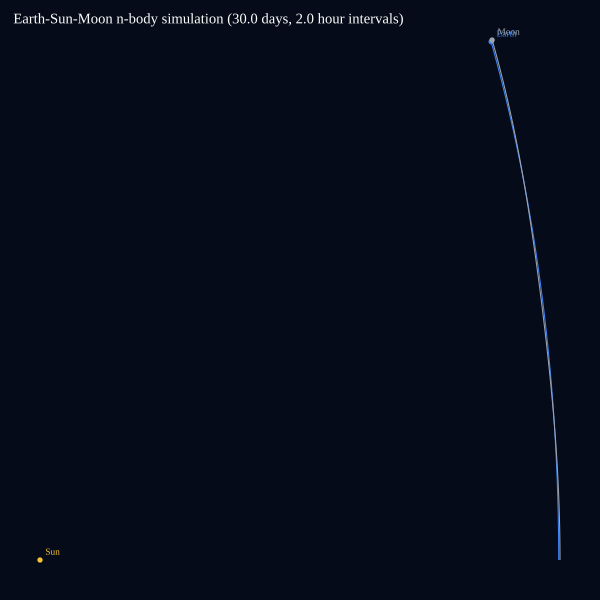

In [20]:
with tempfile.TemporaryDirectory() as tmp_dir:
    csv_file = Path(tmp_dir) / "trajectories.csv"
    svg_file = Path(tmp_dir) / "simulation.svg"
    write_trajectories_csv(trajectories, csv_file)
    write_trajectories_svg(trajectories, svg_file, days, step_hours)
    csv_text = csv_file.read_text(encoding="utf-8")
    svg_text = svg_file.read_text(encoding="utf-8")

rows = csv_text.splitlines()
print(f"CSV: {len(rows) - 1} data rows (3 bodies x {steps + 1} points). The first rows:")
print("\n".join(rows[:4]))
assert len(rows) - 1 == 3 * (steps + 1)


def compare_with_repo(relative_path, new_text):
    """Say whether a file the script wrote into the repo has the same content as ours (new in this notebook)."""
    folders = [Path.cwd(), *Path.cwd().parents]
    repo_file = next((f / relative_path for f in folders if (f / relative_path).exists()), None)
    if repo_file is None:
        return f"{relative_path}: not found, skipped"
    same = repo_file.read_text(encoding="utf-8") == new_text
    return f"{relative_path}: {'identical to' if same else 'DIFFERS from'} the copy produced by the script"


print()
print(compare_with_repo("datasets/earth_sun_moon_trajectories.csv", csv_text))
print(compare_with_repo("visualizations/earth_sun_moon_simulation.svg", svg_text))

# Show the SVG at two-thirds size (the viewBox keeps the drawing proportions).
display(SVG(data=svg_text.replace("width='900' height='900'", "width='600' height='600'", 1)))

Because $x$ and $y$ are stretched independently, the Earth's arc looks more curved than the equal-aspect plot in Part 6 shows it. The Moon's tiny loops are invisible at this scale, and the Sun is the dot in the lower-left corner.

### Putting it together: `run_simulation` and the command line

The script's last two functions are plumbing. `run_simulation(days, step_hours)` converts days and hours into `dt_seconds` and `steps` (exactly as we did in Part 5), builds the system, calls `simulate_n_body`, and passes the result to the two writers with paths inside the repo: `datasets/earth_sun_moon_trajectories.csv` and `visualizations/earth_sun_moon_simulation.svg`. `main()` adds a small command-line interface with `argparse`. From the repository root:

```bash
python gravity/earth_sun_moon_simulation.py --days 30 --step-hours 2
```

Both options are optional, and the values above are the defaults. They are what produced the two files you compared against.

The test file [`test_earth_sun_moon_simulation.py`](test_earth_sun_moon_simulation.py) checks four things: three bodies, finite values, an SVG that contains the labels, and the energy after a year. The check cells above go further, and you can run the tests with `python -m unittest gravity.test_earth_sun_moon_simulation` from the repository root.

---
## Where to go from here

**What you built:** a small N-body engine. Its one physics idea is that gravity is pairwise and additive. Its one numerical idea is that a *symmetric* integrator keeps the energy error bounded, and proportional to $\Delta t^2$, however long you run.

**Where the engine is used next**
- [`keplerian_rv_fit.ipynb`](../machine_learning/keplerian_rv_fit.ipynb) reuses `Body`, `compute_accelerations`, `leapfrog_step` and `total_energy` to simulate a star with a planet and turn the star's wobble into radial-velocity data.
- [`animate_simulation.py`](animate_simulation.py) runs the same `simulate_n_body` for a year and draws the 3D GIF in the README. (It stretches the Moon's distance from the Earth by a factor of 40 so the Moon doesn't disappear inside the Earth's dot.)

**Things to try**
1. Re-run Part 5 with `step_hours = 24` and compare the orbits, then call `relative_energy_error(24.0, 365.25 * 10)` in Part 7. How much worse is the energy error, and is it still bounded?
2. Give the Sun a small velocity so that the total momentum is zero, and check that the centre of mass now stays put.
3. Add Mars or Jupiter as a fourth `Body`. Nothing else in the code needs to change. That is the payoff of writing `compute_accelerations` for *any* list of bodies.
4. Track the total angular momentum $\sum_i m_i (x_i v_{y,i} - y_i v_{x,i})$. Leapfrog conserves it to round-off, far better than it conserves energy. Why? (Hint: what does each kick and each drift do to it when every force is central and comes in equal and opposite pairs?)